In [ ]:
# !pip install -q scikit-learn torch torchvision tqdm


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn import svm
from sklearn.metrics import accuracy_score


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = True
print("Using device:", DEVICE)

scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)


Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


def load_dataset(name):
    if name == "MNIST":
        full = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
        test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
    else:
        full = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
        test = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

    total = len(full)
    train_size = int(0.7 * total)
    val_size = int(0.1 * total)
    test_size2 = total - train_size - val_size

    train_set, val_set, _ = random_split(full, [train_size, val_size, test_size2])
    return train_set, val_set, test


In [4]:
def get_model(model_name, num_classes=10):
    if model_name == "resnet18":
        model = models.resnet18(pretrained=False)
    else:
        model = models.resnet50(pretrained=False)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)


In [5]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)



def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100 * correct / total


In [6]:
def run_experiment(dataset_name, model_name, batch_size, optimizer_name, lr, epochs, pin_memory):
    train_set, val_set, test_set = load_dataset(dataset_name)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, pin_memory=pin_memory)
    val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)
    test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)

    model = get_model(model_name)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    train_accs, val_accs = [], []

    for epoch in range(epochs):
        train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc = evaluate(model, val_loader)
        train_acc = evaluate(model, train_loader)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.2f} | Val Acc: {val_acc:.2f}")

    test_acc = evaluate(model, test_loader)
    print("FINAL TEST ACC:", test_acc)

    # Save graph
    plt.plot(train_accs, label="Train")
    plt.plot(val_accs, label="Val")
    plt.legend()
    plt.title(f"{dataset_name} - {model_name}")
    plt.show()

    return test_acc


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.84MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.1MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1/5 | Train Acc: 97.99 | Val Acc: 97.72


Epoch 2/5 | Train Acc: 98.96 | Val Acc: 98.30


Epoch 3/5 | Train Acc: 99.30 | Val Acc: 98.68


Epoch 4/5 | Train Acc: 99.61 | Val Acc: 98.98


Epoch 5/5 | Train Acc: 99.69 | Val Acc: 98.93
FINAL TEST ACC: 99.15


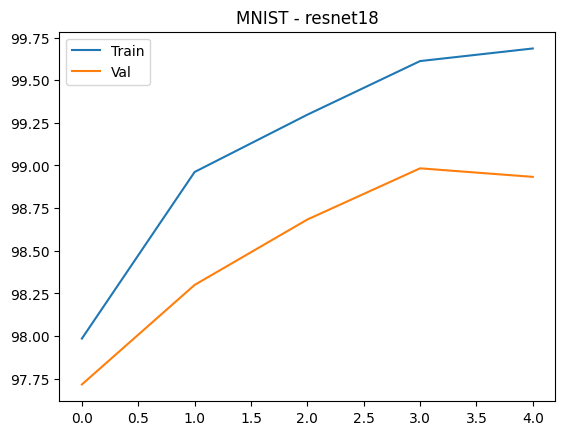

In [7]:
acc = run_experiment(
    dataset_name="MNIST",
    model_name="resnet18",
    batch_size=16,
    optimizer_name="SGD",
    lr=0.001,
    epochs=5,
    pin_memory=True
)


In [1]:
import time
import pandas as pd
import numpy as np
from torchvision import datasets, transforms
from sklearn import svm
from sklearn.metrics import accuracy_score

def load_svm_data(name, max_train=10000, max_test=2000):
    if name == "MNIST":
        train_data = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
        test_data  = datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())
    else:
        train_data = datasets.FashionMNIST("./data", train=True, download=True, transform=transforms.ToTensor())
        test_data  = datasets.FashionMNIST("./data", train=False, download=True, transform=transforms.ToTensor())

    X_train = train_data.data[:max_train].reshape(max_train, -1).numpy() / 255.0
    y_train = train_data.targets[:max_train].numpy()

    X_test = test_data.data[:max_test].reshape(max_test, -1).numpy() / 255.0
    y_test = test_data.targets[:max_test].numpy()

    return X_train, y_train, X_test, y_test


In [2]:
def run_svm_exp(dataset_name, kernel, C=1.0, gamma='scale', degree=3):
    X_train, y_train, X_test, y_test = load_svm_data(dataset_name)

    clf = svm.SVC(kernel=kernel, C=C, gamma=gamma, degree=degree)

    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()

    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    train_time_ms = (end - start) * 1000

    return {
        "Dataset": dataset_name,
        "Kernel": kernel,
        "C": C,
        "Gamma": gamma,
        "Degree": degree,
        "Test Accuracy (%)": round(acc, 2),
        "Training Time (ms)": round(train_time_ms, 2)
    }


In [3]:
results = []

# ---------- MNIST ----------
# RBF
results.append(run_svm_exp("MNIST", "rbf", C=1.0, gamma="scale"))
results.append(run_svm_exp("MNIST", "rbf", C=5.0, gamma="scale"))
results.append(run_svm_exp("MNIST", "rbf", C=10.0, gamma="scale"))
results.append(run_svm_exp("MNIST", "rbf", C=1.0, gamma=0.01))
results.append(run_svm_exp("MNIST", "rbf", C=5.0, gamma=0.01))
results.append(run_svm_exp("MNIST", "rbf", C=10.0, gamma=0.01))

# POLY
results.append(run_svm_exp("MNIST", "poly", C=1.0, degree=2))
results.append(run_svm_exp("MNIST", "poly", C=5.0, degree=2))
results.append(run_svm_exp("MNIST", "poly", C=10.0, degree=2))
results.append(run_svm_exp("MNIST", "poly", C=1.0, degree=3))
results.append(run_svm_exp("MNIST", "poly", C=5.0, degree=3))
results.append(run_svm_exp("MNIST", "poly", C=10.0, degree=3))


# ---------- FashionMNIST ----------
# RBF
results.append(run_svm_exp("FashionMNIST", "rbf", C=1.0, gamma="scale"))
results.append(run_svm_exp("FashionMNIST", "rbf", C=5.0, gamma="scale"))
results.append(run_svm_exp("FashionMNIST", "rbf", C=10.0, gamma="scale"))
results.append(run_svm_exp("FashionMNIST", "rbf", C=1.0, gamma=0.01))
results.append(run_svm_exp("FashionMNIST", "rbf", C=5.0, gamma=0.01))
results.append(run_svm_exp("FashionMNIST", "rbf", C=10.0, gamma=0.01))

# POLY
results.append(run_svm_exp("FashionMNIST", "poly", C=1.0, degree=2))
results.append(run_svm_exp("FashionMNIST", "poly", C=5.0, degree=2))
results.append(run_svm_exp("FashionMNIST", "poly", C=10.0, degree=2))
results.append(run_svm_exp("FashionMNIST", "poly", C=1.0, degree=3))
results.append(run_svm_exp("FashionMNIST", "poly", C=5.0, degree=3))
results.append(run_svm_exp("FashionMNIST", "poly", C=10.0, degree=3))


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]
100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.7MB/s]


In [4]:
df = pd.DataFrame(results)
df


,Dataset,Kernel,C,Gamma,Degree,Test Accuracy (%),Training Time (ms)
0,MNIST,rbf,1.0,scale,3,94.45,7993.38
1,MNIST,rbf,5.0,scale,3,95.40,7411.84
2,MNIST,rbf,10.0,scale,3,95.55,8001.53
3,MNIST,rbf,1.0,0.01,3,93.25,7175.44
4,MNIST,rbf,5.0,0.01,3,95.40,9403.81
5,MNIST,rbf,10.0,0.01,3,95.45,6162.32
6,MNIST,poly,1.0,scale,2,94.15,6056.24
7,MNIST,poly,5.0,scale,2,95.05,5633.33
8,MNIST,poly,10.0,scale,2,95.20,5204.85
9,MNIST,poly,1.0,scale,3,93.40,8414.45


In [1]:
#Q2
!pip install thop
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import time
from thop import profile # For FLOPs counting

In [4]:
# --- CONFIGURATION ---
BATCH_SIZE = 16
LR = 0.001
EPOCHS_CPU = 1  # Keep low (1) for CPU to save time
EPOCHS_GPU = 3  # Can be higher for GPU
DATASET_NAME = 'FashionMNIST'

# --- 1. DATA SETUP ---
# ResNet requires 3 channels, we will modify model later.
# We resize to 32x32 for speed (Standard ResNet is 224x224, but that is too heavy for CPU testing)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download Data
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# --- 2. MODEL BUILDER ---
def get_model(model_name, device):
    if model_name == 'resnet18':
        model = models.resnet18(weights=None)
    elif model_name == 'resnet50':
        model = models.resnet50(weights=None)

    # Modify for 1 Channel (Grayscale)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    return model.to(device)

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 231kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.31MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.4MB/s]


In [5]:
def calculate_flops(model, device):
    # Create a dummy input of size (Batch_Size, Channel, Height, Width)
    dummy_input = torch.randn(1, 1, 32, 32).to(device)
    macs, params = profile(model, inputs=(dummy_input, ), verbose=False)

    # FLOPs is roughly 2 * MACs (Multiply-Accumulates)
    flops = 2 * macs
    return flops

In [6]:
def run_experiment(device_type, model_name, optimizer_name):
    # Setup Device
    device = torch.device("cuda" if device_type == "GPU" and torch.cuda.is_available() else "cpu")
    print(f"   -> Running on {device}...")

    # Load Model
    model = get_model(model_name, device)

    # Calculate FLOPs (Only need to do this once per model type)
    flops = calculate_flops(model, device)

    # Loaders
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

    # Optimizer
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=LR)
    else:
        optimizer = optim.Adam(model.parameters(), lr=LR)

    criterion = nn.CrossEntropyLoss()

    # Determine Epochs
    epochs = EPOCHS_CPU if device_type == 'CPU' else EPOCHS_GPU

    # --- START TIMER ---
    start_time = time.time()

    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # --- END TIMER ---
    end_time = time.time()
    total_train_time_ms = (end_time - start_time) * 1000  # Convert to ms

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy, total_train_time_ms, flops



In [ ]:
experiments_cpu = [
    # CPU Experiments
    {'compute': 'CPU', 'model': 'resnet18', 'optim': 'SGD'},
    {'compute': 'CPU', 'model': 'resnet18', 'optim': 'Adam'},
    {'compute': 'CPU', 'model': 'resnet32', 'optim': 'SGD'},
    {'compute': 'CPU', 'model': 'resnet50', 'optim': 'SGD'},
    {'compute': 'CPU', 'model': 'resnet32', 'optim': 'Adam'},
    {'compute': 'CPU', 'model': 'resnet50', 'optim': 'Adam'},

]

print(f"{'Compute':<8} | {'Model':<10} | {'Optim':<6} | {'Acc (%)':<8} | {'Time (ms)':<12} | {'FLOPs':<15}")
print("-" * 75)

for exp in experiments_cpu:
    acc, time_ms, flops = run_experiment(exp['compute'], exp['model'], exp['optim'])

    print(f"{exp['compute']:<8} | {exp['model']:<10} | {exp['optim']:<6} | {acc:<8.2f} | {time_ms:<12.0f} | {flops:<15.0f}")


Compute  | Model      | Optim  | Acc (%)  | Time (ms)    | FLOPs          
---------------------------------------------------------------------------
   -> Running on cpu...
CPU      | resnet18   | SGD    | 85.26    | 520452       | 72243200       


In [ ]:
experiments_gpu = [
    # GPU Experiments
    {'compute': 'GPU', 'model': 'resnet18', 'optim': 'SGD'},
    {'compute': 'GPU', 'model': 'resnet18', 'optim': 'Adam'},
    {'compute': 'GPU', 'model': 'resnet32', 'optim': 'SGD'},
    {'compute': 'GPU', 'model': 'resnet50', 'optim': 'SGD'},
    {'compute': 'GPU', 'model': 'resnet32', 'optim': 'Adam'},
    {'compute': 'GPU', 'model': 'resnet50', 'optim': 'Adam'},
]


print(f"{'Compute':<8} | {'Model':<10} | {'Optim':<6} | {'Acc (%)':<8} | {'Time (ms)':<12} | {'FLOPs':<15}")
print("-" * 75)

for exp in experiments_gpu:
    acc, time_ms, flops = run_experiment(exp['compute'], exp['model'], exp['optim'])

    print(f"{exp['compute']:<8} | {exp['model']:<10} | {exp['optim']:<6} | {acc:<8.2f} | {time_ms:<12.0f} | {flops:<15.0f}")


Compute  | Model      | Optim  | Acc (%)  | Time (ms)    | FLOPs          
---------------------------------------------------------------------------
   -> Running on cuda...
GPU      | resnet18   | SGD    | 88.42    | 147645       | 72243200       
   -> Running on cuda...
GPU      | resnet18   | Adam   | 90.24    | 155440       | 72243200       
   -> Running on cuda...
GPU      | resnet50   | SGD    | 83.51    | 253736       | 169529344      
   -> Running on cuda...
GPU      | resnet50   | Adam   | 85.64    | 323341       | 169529344      
